# Mann–Whitney U analysis of TESIS run artifacts

One observation is **one run**, using its recorded selected-method score. This
notebook reads saved JSON; it makes no DVWA or LLM requests and does not alter
source artifacts. Configure the condition and model comparisons below, then
**Run All**. Tables, a box plot with individual observations, and empirical
cumulative distributions accompany a two-sided test and an effect size.

**Three comparisons run together:**

1. Linear vs AKG-guided, using `Smethod` from archived `openai_compatible` runs.
2. Linear vs AKG-guided, using recorded `Srun` from the same condition groups.
3. Model A (GPT-5.6 Luna) vs model B (DeepSeek V4 Flash), using recorded
   `Srun` from both Linear and AKG-guided runs, pooled as in the findings report.

The September acceptance matrix contains only AKG-guided runs and cannot supply
this condition comparison. The archive is an exploratory `llm_mutation_only`
experiment, not the primary hybrid experiment. Its historical `Soutput` and
`Srun` have a known scoring issue; this notebook preserves recorded scores.

References: [methodology §§9–13](../docs/reference/summary_en.md#13-analysis-plan),
[Indonesian methodology](../docs/reference/summary_id.md),
[experiment findings and limitations](../docs/reference/experiment_findings_codebase_report.md),
and [SciPy's Mann–Whitney U documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html).


## Setup

Open this notebook with a Python 3.12+ kernel, with its working directory at the
repository root or `evaluation/`. If needed, run this in a separate cell once:

```python
%pip install "scipy==1.17.1" "matplotlib>=3.9" ipykernel
```

Restart the kernel after installation. These are notebook dependencies; the
runtime project dependencies are unchanged. Exported evidence goes to
`results/analysis/mann-whitney/` and is replaced when rerunning this analysis.
The additional condition `Srun` test exports to `OUTPUT_DIR / "condition-srun"`;
the model comparison exports to `OUTPUT_DIR / "models"`. Each comparison
preserves the others' results. Use a different `OUTPUT_DIR` to keep
several notebook executions.


In [1]:
%matplotlib inline
import csv
import hashlib
import json
from collections import Counter
from html import escape
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy
from IPython.display import HTML, display
from scipy.stats import PermutationMethod, mannwhitneyu

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").is_file():
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").is_file():
    raise FileNotFoundError("Run the notebook from the TESIS root or evaluation/.")
print(f"SciPy {scipy.__version__}; Matplotlib {matplotlib.__version__}; NumPy {np.__version__}")


SciPy 1.17.1; Matplotlib 3.11.2; NumPy 2.5.3


In [2]:
# Choose authoritative matrix JSON files OR primary individual run JSON files.
# Do not combine a matrix with its individual runs or an evidence re-export.
INPUT_FILES = sorted(
    (ROOT / "results/thesis-experiment-2026-08-21-v2").glob("*/aggregate/*.matrix.json")
)
GROUP_FIELD = "experiment_condition"
GROUPS = ("linear_hybrid", "akg_guided_hybrid")  # A, B: effect direction is A minus B
METRIC = "method_score"
FILTERS = {"provider": "openai_compatible"}  # Add surface, security_level, target_method, etc.
# Additional model comparison: independent of the condition-test filters.
MODEL_GROUPS = ("gpt-5.6-luna", "deepseek-v4-flash")  # Model A, model B
MODEL_METRIC = "composite_score"  # Srun; retain the documented historical caveat.
MODEL_FILTERS = {}  # Pool both conditions; optionally filter surface, level, etc.

ALPHA = 0.05
SEED = 20260928
OUTPUT_DIR = ROOT / "results/analysis/mann-whitney"

# Supported scalar scores: method_score (Smethod), exploitation_score (Sexploit),
# chain_score (Schain), output_score (Soutput), composite_score (Srun).
# payload_scores is candidate-level; do not treat candidates as independent runs.
# To restrict the model comparison to one condition:
# MODEL_FILTERS = {"experiment_condition": "akg_guided_hybrid"}
# For the acceptance matrix's optional payload-mode comparison:
# INPUT_FILES = sorted((ROOT / "results/runs/matrix-2026-09-28-4").glob("*.matrix.json"))
# GROUP_FIELD, GROUPS = "payload_mode", ("static_only", "hybrid")


## Interpretation and sampling

Mann–Whitney assumes independent observations and compares score distributions.
`H₀`: both groups have the same underlying distribution; `H₁`: they differ.
It does not automatically test median differences. Medians are descriptive;
interpreting a location difference requires comparable distribution shapes.

Linear/AKG coordinates in the archive are **matched**. Their Mann–Whitney test is
supplementary; a paired analysis should be primary, as the findings report says.
Matching is checked below, but lack of detected matches does not establish
independence. Repeated DVWA sessions and pooled methods/levels can also create
dependence or obscure differences. Use `FILTERS` for comparisons within a model,
surface, level, and target method; pooling is exploratory.

All recorded statuses, including `error` and fallback runs, stay in the analysis
when their score is numeric. Missing, boolean, nonnumeric, or nonfinite scores
are explicitly excluded and exported; they are never replaced by zero. Recorded
zero scores stay. Repeated execution IDs raise an error instead of double-counting
aggregate/sidecar exports. No inference is possible without two nonempty groups.
All three comparisons are exploratory and report unadjusted p-values. Establish a
multiple-comparison plan before making confirmatory claims. The model test
uses `MODEL_FILTERS`, independently of `FILTERS`: the archive serves the two
models through different providers. Results describe those recorded model
and provider configurations, with both conditions pooled by default.


In [3]:
SCORE_LABELS = {
    "method_score": "Smethod", "exploitation_score": "Sexploit",
    "chain_score": "Schain", "output_score": "Soutput", "composite_score": "Srun",
}
IDENTITY_FIELDS = ["provider", "model", "experiment_condition", "surface",
                   "security_level", "target_method", "payload_mode", "repeat_index"]
if not INPUT_FILES:
    raise FileNotFoundError("No input files. Set INPUT_FILES to saved matrix or primary run JSON files.")

def field(run, key):
    # Older artifacts store repeat_index only inside config.
    value = run.get(key)
    return run.get("config", {}).get(key) if value is None else value

records, sources, seen = [], [], set()
for file in INPUT_FILES:
    file = Path(file)
    content = file.read_bytes()
    document = json.loads(content)
    batch = document.get("runs", [document])
    if not isinstance(batch, list) or not batch:
        raise ValueError(f"Expected run JSON or a nonempty matrix runs list: {file}")
    source_path = file.resolve()
    sources.append({"path": str(source_path.relative_to(ROOT) if source_path.is_relative_to(ROOT) else source_path),
                    "sha256": hashlib.sha256(content).hexdigest(), "runs": len(batch)})
    for run in batch:
        if not isinstance(run, dict) or not run.get("execution_id") or "status" not in run:
            raise ValueError(f"Expected primary run artifact with execution_id and status: {file}")
        execution_id = run["execution_id"]
        if execution_id in seen:
            raise ValueError(f"Duplicate execution_id {execution_id}: choose one authoritative export.")
        seen.add(execution_id)
        records.append({**{key: field(run, key) for key in IDENTITY_FIELDS},
                        "execution_id": execution_id, "status": run["status"],
                        **{key: run.get(key) for key in SCORE_LABELS}, "source_artifact": sources[-1]["path"]})



The signed rank-biserial effect is `2 × U(A) / (nA × nB) − 1`, counting ties
as half a win. It ranges from −1 (all A scores lower) to +1 (all A scores higher).
Zero indicates no net rank advantage; it does **not** prove equal distributions.
No fixed “small/medium/large” labels are imposed.

Small untied samples use the exact U distribution. Small tied samples use a
seeded permutation calculation (up to 10,000 resamples); larger tied samples use
SciPy's asymptotic tie correction with continuity correction. These calculation
choices do not repair dependence in the experiment design.


In [4]:
def compare_runs(group_field, groups, metric, filters, output_dir):
    """Compare recorded run scores and export one comparison without changing shared inputs."""
    assert metric in SCORE_LABELS, f"Choose a scalar score: {list(SCORE_LABELS)}"
    assert len(groups) == 2 and groups[0] != groups[1], "Choose two distinct groups."
    assert group_field in IDENTITY_FIELDS, f"Choose a group field: {IDENTITY_FIELDS}"
    assert set(filters) <= set(IDENTITY_FIELDS), "Unknown filter field."
    assert 0 < ALPHA < 1

    filtered = [r for r in records if all(r[key] == value for key, value in filters.items())]
    selected = [{**{key: value for key, value in r.items() if key not in SCORE_LABELS},
                 "score": r.get(metric)} for r in filtered if r[group_field] in groups]
    observations, excluded = [], []
    for row in selected:
        value = row["score"]
        reason = ""
        if value is None:
            reason = "missing score"
        elif isinstance(value, bool) or not isinstance(value, (int, float)):
            reason = "nonnumeric score (including boolean)"
        elif not np.isfinite(value):
            reason = "nonfinite score"
        elif not 0 <= value <= 4:
            raise ValueError(f"Score outside 0–4: {row['execution_id']} = {value}")
        if reason:
            excluded.append({**row, "reason": reason})
        else:
            observations.append({**row, "score": float(value)})

    samples = [np.array([r["score"] for r in observations if r[group_field] == group]) for group in groups]
    print(f"Loaded {len(records)} unique runs; {len(filtered)} after filters; {len(selected)} in chosen groups.")
    print(f"Included {len(observations)} scores; excluded {len(excluded)}: {dict(Counter(r['reason'] for r in excluded))}")
    for group in groups:
        print(group, "recorded statuses:", dict(Counter(r["status"] for r in selected if r[group_field] == group)),
              "excluded scores:", sum(r[group_field] == group for r in excluded))
    if any(len(sample) == 0 for sample in samples):
        raise ValueError("Mann–Whitney requires two nonempty groups. Check INPUT_FILES, the comparison filters/groups and missing scores.")

    x, y = samples
    pooled = np.concatenate(samples)
    has_ties = len(np.unique(pooled)) < len(pooled)
    if has_ties and min(len(x), len(y)) < 10:
        p_method = "permutation"
        method = PermutationMethod(n_resamples=10000, rng=np.random.default_rng(SEED))
    elif not has_ties and min(len(x), len(y)) <= 8:
        p_method = method = "exact"
    else:
        p_method = method = "asymptotic"  # Tie correction and continuity correction.

    test = mannwhitneyu(x, y, alternative="two-sided", method=method, use_continuity=True, nan_policy="raise")
    u_a, p_value = float(test.statistic), float(test.pvalue)
    rank_biserial = 2 * u_a / (len(x) * len(y)) - 1

    pair_fields = [key for key in IDENTITY_FIELDS if key != group_field]
    if group_field in {"provider", "model"}:
        pair_fields = [key for key in pair_fields if key not in {"provider", "model"}]
    coordinates = [Counter(tuple(r[key] for key in pair_fields) for r in observations
                           if r[group_field] == group and all(r[key] is not None for key in pair_fields))
                   for group in groups]
    matched_coordinates = sum((coordinates[0] & coordinates[1]).values())
    warnings = []
    if matched_coordinates:
        warnings.append(f"{matched_coordinates} matched coordinates: Mann–Whitney is supplementary; use a paired primary analysis.")
    if any("thesis-experiment-2026-08-21-v2" in str(file) for file in INPUT_FILES):
        warnings.append("Historical mutation-only experiment with forced targets; Soutput/Srun scoring caveat applies. Not final hybrid thesis evidence.")
    if excluded:
        warnings.append("Missing scores can bias this comparison; inspect excluded.csv and group counts.")

    summaries = [{"group": group, "n": len(values), "mean": float(np.mean(values)),
                  "median": float(np.median(values)), "q1": float(np.quantile(values, .25)),
                  "q3": float(np.quantile(values, .75))} for group, values in zip(groups, samples)]
    header = "<tr>" + "".join(f"<th>{key}</th>" for key in summaries[0]) + "</tr>"
    body = "".join("<tr>" + "".join(f"<td>{escape(str(round(v, 4) if isinstance(v, float) else v))}</td>"
                                  for v in row.values()) + "</tr>" for row in summaries)
    display(HTML("<table>" + header + body + "</table>"))
    print(f"{SCORE_LABELS[metric]}: U(A)={u_a:g}; U(B)={len(x)*len(y)-u_a:g}; p={p_value:.6g} ({p_method}, two-sided)")
    print(f"Rank-biserial (A minus B) = {rank_biserial:.4f}; positive means A tends to have higher scores.")
    print("Under the independent-sample assumption:",
          "reject H₀ at the configured alpha." if p_value < ALPHA else "do not reject H₀; this does not establish equivalence.")
    for warning in warnings:
        print("CAUTION:", warning)

    result = {
        "metric": metric, "group_field": group_field, "group_a": groups[0], "group_b": groups[1],
        "n_a": len(x), "n_b": len(y), "u_a": u_a, "u_b": len(x)*len(y)-u_a,
        "p_value": p_value, "p_method": p_method, "alternative": "two-sided", "alpha": ALPHA,
        "rank_biserial_a_minus_b": rank_biserial, "ties": has_ties,
        "matched_coordinates": matched_coordinates, "warnings": warnings, "summary": summaries,
        "filters": filters, "loaded_runs": len(records), "filtered_runs": len(filtered),
        "selected_runs": len(selected), "excluded_scores": len(excluded),
        "statuses": {group: dict(Counter(r["status"] for r in selected if r[group_field] == group)) for group in groups},
        "seed": SEED, "permutation_resamples": 10000 if p_method == "permutation" else None,
        "continuity_correction": p_method == "asymptotic", "sources": sources,
        "versions": {"scipy": scipy.__version__, "numpy": np.__version__, "matplotlib": matplotlib.__version__},
    }

    colors = ("#0072B2", "#D55E00")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
    labels = [f"{group}\n(n={len(values)})" for group, values in zip(groups, samples)]
    boxes = axes[0].boxplot(samples, tick_labels=labels, patch_artist=True, showfliers=False,
                            medianprops={"color": "black", "linewidth": 1.5})
    rng = np.random.default_rng(SEED)
    for i, (values, color, box) in enumerate(zip(samples, colors, boxes["boxes"]), start=1):
        box.set_facecolor(color)
        box.set_alpha(.25)
        axes[0].scatter(i + rng.uniform(-.13, .13, len(values)), values, s=18, alpha=.45, color=color)
    axes[0].set(title="Recorded scores and quartiles", ylabel=SCORE_LABELS[metric], ylim=(-.15, 4.15))
    axes[0].grid(axis="y", alpha=.2)
    for values, group, color, style in zip(samples, groups, colors, ("-", "--")):
        ordered = np.sort(values)
        axes[1].step(np.r_[0, ordered, 4], np.r_[0, np.arange(1, len(values)+1)/len(values), 1],
                     where="post", label=group, color=color, linestyle=style, linewidth=2)
    axes[1].set(title="Empirical cumulative distribution", xlabel=SCORE_LABELS[metric],
                ylabel="Fraction of runs ≤ score", xlim=(-.1, 4.1), ylim=(-.02, 1.02))
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=.2)
    scope = "Supplementary: matched coordinates" if matched_coordinates else "Exploratory: verify independence"
    fig.suptitle(f"{SCORE_LABELS[metric]} · U(A)={u_a:g}, p={p_value:.4g}, rank-biserial={rank_biserial:.3f}\n{scope}")

    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_dir / "distribution.png", dpi=180)
    fig.savefig(output_dir / "distribution.svg")
    plt.show()
    plt.close(fig)
    (output_dir / "analysis.json").write_text(json.dumps(result, indent=2, allow_nan=False) + "\n")
    columns = ["execution_id", *IDENTITY_FIELDS, "status", "score", "source_artifact"]
    for filename, rows, fields in [("observations.csv", observations, columns),
                                   ("excluded.csv", excluded, columns + ["reason"])]:
        with (output_dir / filename).open("w", newline="", encoding="utf-8") as handle:
            writer = csv.DictWriter(handle, fieldnames=fields)
            writer.writeheader()
            writer.writerows(rows)
    print("Saved analysis.json, observations.csv, excluded.csv, distribution.png and distribution.svg to", output_dir)
    return result, observations, excluded


## 1. Linear vs AKG-guided — Smethod

The original comparison uses `GROUPS`, `METRIC` and `FILTERS` above.
Default: 81 Linear runs vs 81 AKG-guided runs from `openai_compatible`, using `Smethod`.


Loaded 324 unique runs; 162 after filters; 162 in chosen groups.
Included 162 scores; excluded 0: {}
linear_hybrid recorded statuses: {'error': 59, 'success': 22} excluded scores: 0
akg_guided_hybrid recorded statuses: {'error': 56, 'success': 25} excluded scores: 0


group,n,mean,median,q1,q3
linear_hybrid,81,2.4074,3.0,1.0,3.0
akg_guided_hybrid,81,2.4074,3.0,1.0,3.0


Smethod: U(A)=3280.5; U(B)=3280.5; p=1 (asymptotic, two-sided)
Rank-biserial (A minus B) = 0.0000; positive means A tends to have higher scores.
Under the independent-sample assumption: do not reject H₀; this does not establish equivalence.
CAUTION: 81 matched coordinates: Mann–Whitney is supplementary; use a paired primary analysis.
CAUTION: Historical mutation-only experiment with forced targets; Soutput/Srun scoring caveat applies. Not final hybrid thesis evidence.


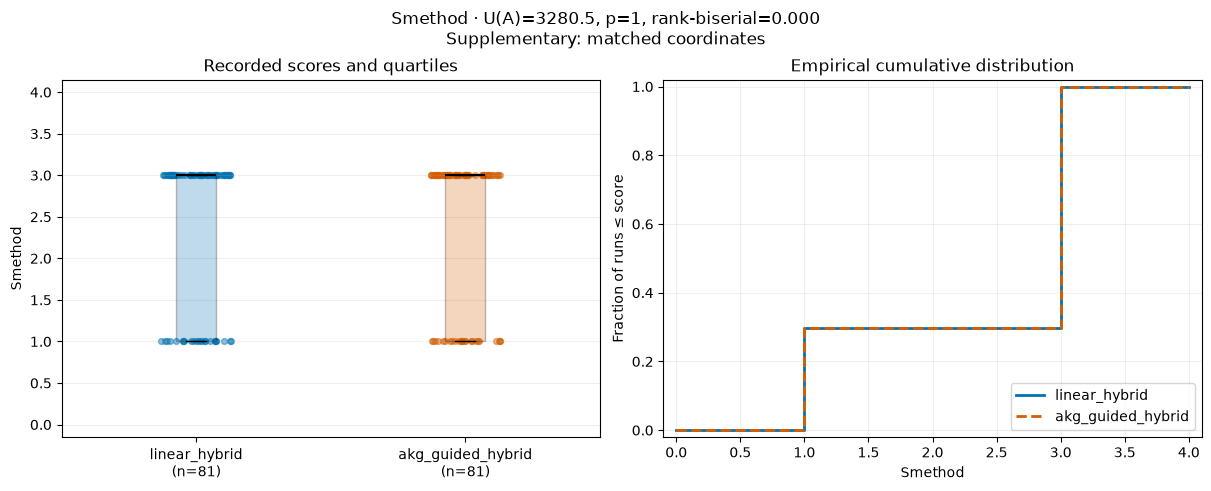

Saved analysis.json, observations.csv, excluded.csv, distribution.png and distribution.svg to /home/kevin/coding/tesis/results/analysis/mann-whitney


In [5]:
result, observations, excluded = compare_runs(
    GROUP_FIELD, GROUPS, METRIC, FILTERS, OUTPUT_DIR
)


## 2. Linear vs AKG-guided — Srun

This additional Mann–Whitney test compares the recorded composite score
(`Srun`, artifact field `composite_score`) using the same `GROUP_FIELD`,
`GROUPS` and `FILTERS` as the original condition comparison. The default
is 81 runs per condition from `openai_compatible`. Set `FILTERS = {}`
to pool both archived models, giving 162 runs per condition for both
condition tests, matching the thesis's grouping. Scores are neither
recomputed nor averaged across runs.

The archive's documented `Soutput` scoring issue affects `Srun`, and
matched coordinates make this test supplementary. Inspect the component
scores alongside the composite; these exploratory results do not
establish AKG effectiveness. Missing-score exclusions are reported
separately for each metric, so eligible sample sizes can differ.


Loaded 324 unique runs; 162 after filters; 162 in chosen groups.
Included 162 scores; excluded 0: {}
linear_hybrid recorded statuses: {'error': 59, 'success': 22} excluded scores: 0
akg_guided_hybrid recorded statuses: {'error': 56, 'success': 25} excluded scores: 0


group,n,mean,median,q1,q3
linear_hybrid,81,1.2037,1.1,0.7,2.1
akg_guided_hybrid,81,1.2407,1.1,0.7,2.1


Srun: U(A)=3193.5; U(B)=3367.5; p=0.764159 (asymptotic, two-sided)
Rank-biserial (A minus B) = -0.0265; positive means A tends to have higher scores.
Under the independent-sample assumption: do not reject H₀; this does not establish equivalence.
CAUTION: 81 matched coordinates: Mann–Whitney is supplementary; use a paired primary analysis.
CAUTION: Historical mutation-only experiment with forced targets; Soutput/Srun scoring caveat applies. Not final hybrid thesis evidence.


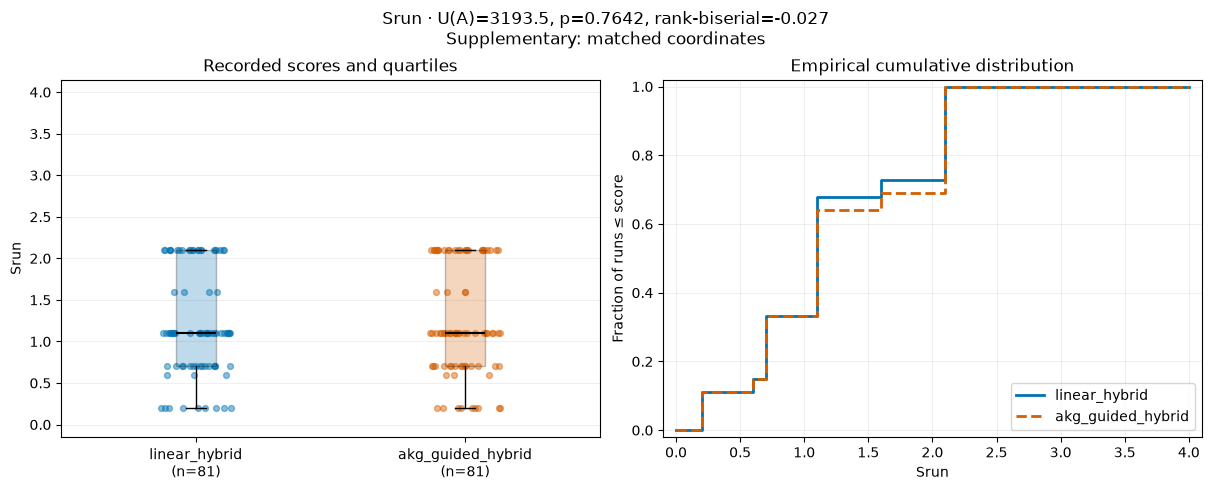

Saved analysis.json, observations.csv, excluded.csv, distribution.png and distribution.svg to /home/kevin/coding/tesis/results/analysis/mann-whitney/condition-srun


In [6]:
condition_srun_result, condition_srun_observations, condition_srun_excluded = compare_runs(
    GROUP_FIELD, GROUPS, "composite_score", FILTERS, OUTPUT_DIR / "condition-srun"
)


## 3. Model A vs model B

Default: **GPT-5.6 Luna vs DeepSeek V4 Flash**, using each run's recorded
**composite score (`Srun`)**. Both Linear and AKG-guided runs are pooled:
162 runs per model in the archive. One observation is one run; the two
condition scores are not averaged into a single observation. `MODEL_GROUPS`,
`MODEL_METRIC` and `MODEL_FILTERS` control this additional comparison.

The historical `Soutput` issue also affects `Srun`; scores are not recomputed
here. Matched-coordinate and pooling limitations apply. This reproduces an
exploratory reference-report comparison, rather than establishing model
superiority. Both condition tests and their exports remain available.


Loaded 324 unique runs; 324 after filters; 324 in chosen groups.
Included 324 scores; excluded 0: {}
gpt-5.6-luna recorded statuses: {'error': 104, 'success': 58} excluded scores: 0
deepseek-v4-flash recorded statuses: {'error': 115, 'success': 47} excluded scores: 0


group,n,mean,median,q1,q3
gpt-5.6-luna,162,1.3025,1.1,0.7,2.1
deepseek-v4-flash,162,1.2222,1.1,0.7,2.1


Srun: U(A)=13882; U(B)=12362; p=0.351722 (asymptotic, two-sided)
Rank-biserial (A minus B) = 0.0579; positive means A tends to have higher scores.
Under the independent-sample assumption: do not reject H₀; this does not establish equivalence.
CAUTION: 162 matched coordinates: Mann–Whitney is supplementary; use a paired primary analysis.
CAUTION: Historical mutation-only experiment with forced targets; Soutput/Srun scoring caveat applies. Not final hybrid thesis evidence.


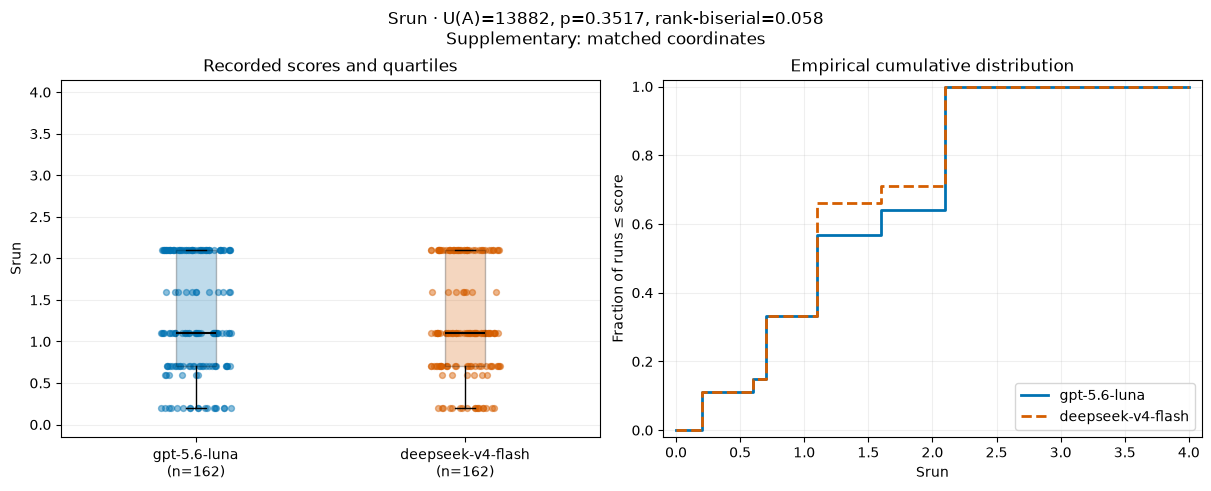

Saved analysis.json, observations.csv, excluded.csv, distribution.png and distribution.svg to /home/kevin/coding/tesis/results/analysis/mann-whitney/models


In [7]:
model_result, model_observations, model_excluded = compare_runs(
    "model", MODEL_GROUPS, MODEL_METRIC, MODEL_FILTERS, OUTPUT_DIR / "models"
)


In [8]:
# Small known-answer check, including U direction. Run All verifies all three comparisons.
known = mannwhitneyu([1, 2, 3], [4, 5, 6], alternative="two-sided", method="exact")
assert known.statistic == 0 and np.isclose(known.pvalue, .1)
assert 2 * known.statistic / 9 - 1 == -1
for comparison, rows in [(result, observations),
                         (condition_srun_result, condition_srun_observations),
                         (model_result, model_observations)]:
    assert np.isfinite(comparison["p_value"]) and 0 <= comparison["p_value"] <= 1
    assert -1 <= comparison["rank_biserial_a_minus_b"] <= 1
    assert len(rows) == comparison["n_a"] + comparison["n_b"]
print("Known-answer and all three comparison checks passed.")


Known-answer and all three comparison checks passed.
